In [1]:
!pip install yfinance tensorflow scikit-learn matplotlib pandas numpy -q

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1775336696.079595     137 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775336696.093398     137 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775336696.209318     137 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1775336701.526399     137 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775336701.536760     137 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
TICKER = 'AAPL'
START_DATE = '2018-01-01'
END_DATE = '2024-01-01'
SEQ_LEN = 60
BATCH_SIZE = 32
EPOCHS = 100
TEST_SPLIT = 0.2

In [4]:
def load_stock_data(ticker, start, end):
    try:
        import yfinance as yf
        raw = yf.download(ticker, start=start, end=end, auto_adjust=True)
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        df = raw[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
        if len(df) > 100:
            print(f'Downloaded {len(df)} rows from Yahoo Finance')
            return df
    except Exception:
        pass

    print('Yahoo Finance unavailable — generating synthetic AAPL-like data')
    dates = pd.date_range(start=start, end=end, freq='B')
    n = len(dates)
    close = 150.0 * np.exp(np.cumsum(np.random.normal(0.0003, 0.015, n)))
    high = close * (1 + np.abs(np.random.normal(0, 0.008, n)))
    low = close * (1 - np.abs(np.random.normal(0, 0.008, n)))
    open_ = close * (1 + np.random.normal(0, 0.005, n))
    volume = np.random.randint(50_000_000, 150_000_000, n).astype(float)
    df = pd.DataFrame({'Open': open_, 'High': high, 'Low': low,
                       'Close': close, 'Volume': volume}, index=dates)
    return df

df = load_stock_data(TICKER, START_DATE, END_DATE)

df['MA_7'] = df['Close'].rolling(7).mean()
df['MA_21'] = df['Close'].rolling(21).mean()
delta = df['Close'].pct_change()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain / loss))
df['Volatility'] = df['Close'].rolling(10).std()
df.dropna(inplace=True)

print(f'Final dataset shape: {df.shape}')
df.tail()

Failed to get ticker 'AAPL' reason: Impersonating chrome136 is not supported


[*********************100%***********************]  1 of 1 completed



1 Failed download:


['AAPL']: ImpersonateError('Impersonating chrome136 is not supported')


Yahoo Finance unavailable — generating synthetic AAPL-like data
Final dataset shape: (1546, 9)


,Open,High,Low,Close,Volume,MA_7,MA_21,RSI,Volatility
2023-12-26,713.193912,721.911589,711.366233,714.377465,111269940.0,716.659296,713.054336,55.861327,7.741538
2023-12-27,693.953517,689.474116,688.021258,689.073458,89171924.0,714.085236,712.587642,39.754645,11.017853
2023-12-28,701.181877,700.780771,697.373920,698.481408,90901228.0,711.430654,711.718997,37.657047,11.623822
2023-12-29,705.898685,706.960531,703.572980,706.456211,88494992.0,711.111693,711.453141,42.378504,11.418083
2024-01-01,704.777098,703.903890,696.528401,703.692385,110879244.0,708.074441,711.350498,42.073872,11.598618


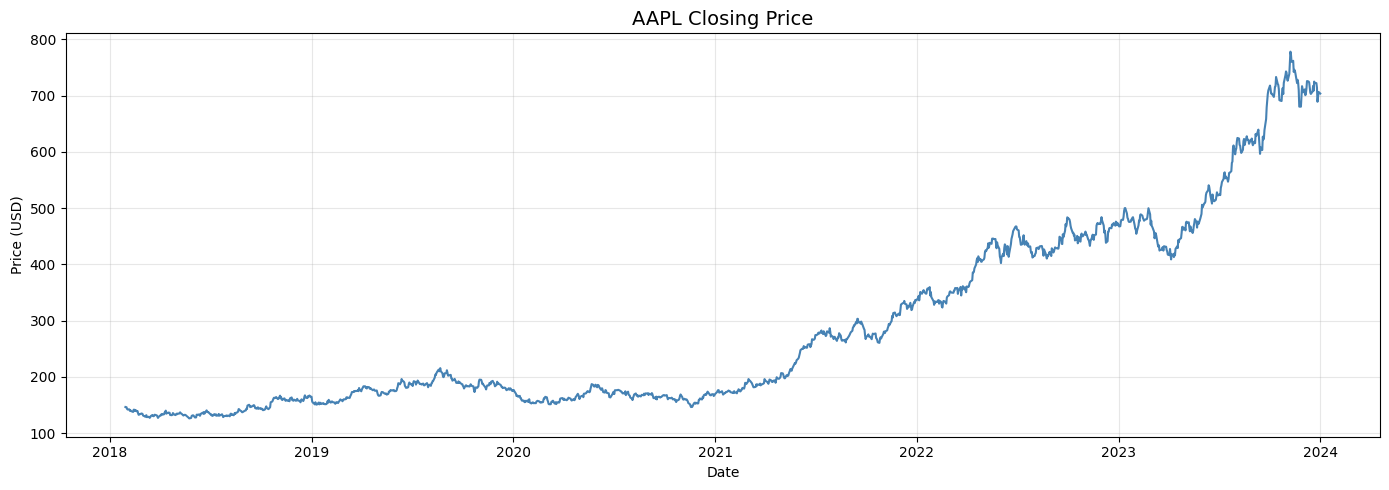

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(df['Close'], color='steelblue', linewidth=1.5)
plt.title(f'{TICKER} Closing Price', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_7', 'MA_21', 'RSI', 'Volatility']
target_col = 'Close'

scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

scaled_features = scaler_features.fit_transform(df[feature_cols])
scaled_target = scaler_target.fit_transform(df[[target_col]])

def create_sequences(features, target, seq_len):
    X, y = [], []
    for i in range(seq_len, len(features)):
        X.append(features[i - seq_len:i])
        y.append(target[i])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_features, scaled_target, SEQ_LEN)

split = int(len(X) * (1 - TEST_SPLIT))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (1188, 60, 9)  |  Test: (298, 60, 9)


In [7]:
def build_cnn_lstm(input_shape):
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_cnn_lstm((SEQ_LEN, X_train.shape[2]))
model.summary()

E0000 00:00:1775336705.688481     137 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 60, 64)         │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 60, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,369 (821.75 KB)

 Trainable params: 209,985 (820.25 KB)

 Non-trainable params: 384 (1.50 KB)

In [8]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


 1/34 ━━━━━━━━━━━━━━━━━━━━ 5:00 9s/step - loss: 0.0244 - mae: 0.1294

 2/34 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0346 - mae: 0.1414

 3/34 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0367 - mae: 0.1442

 4/34 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0376 - mae: 0.1464

...

30/34 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 4.5078e-04 - mae: 0.0154

31/34 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 4.4915e-04 - mae: 0.0154

32/34 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 4.4756e-04 - mae: 0.0154

33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 4.4615e-04 - mae: 0.0153

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 3.9909e-04 - mae: 0.0144 - val_loss: 0.0034 - val_mae: 0.0523 - learning_rate: 2.5000e-04


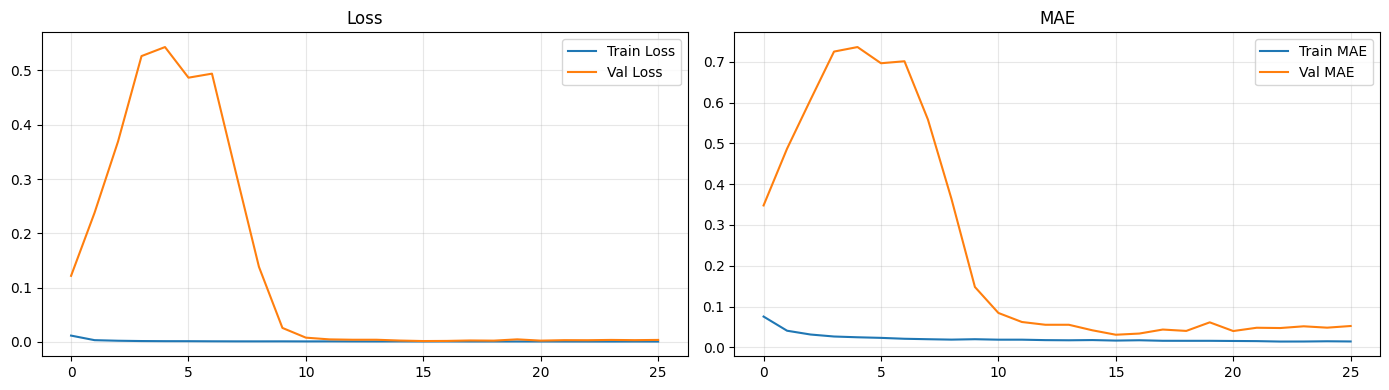

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
y_pred_scaled = model.predict(X_test)
y_pred = scaler_target.inverse_transform(y_pred_scaled)
y_true = scaler_target.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'RMSE  : ${rmse:.2f}')
print(f'MAE   : ${mae:.2f}')
print(f'MAPE  : {mape:.2f}%')
print(f'R²    : {r2:.4f}')

 1/10 ━━━━━━━━━━━━━━━━━━━━ 3s 437ms/step

 5/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step 

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step


RMSE  : $150.82
MAE   : $115.60
MAPE  : 18.42%
R²    : -0.9788


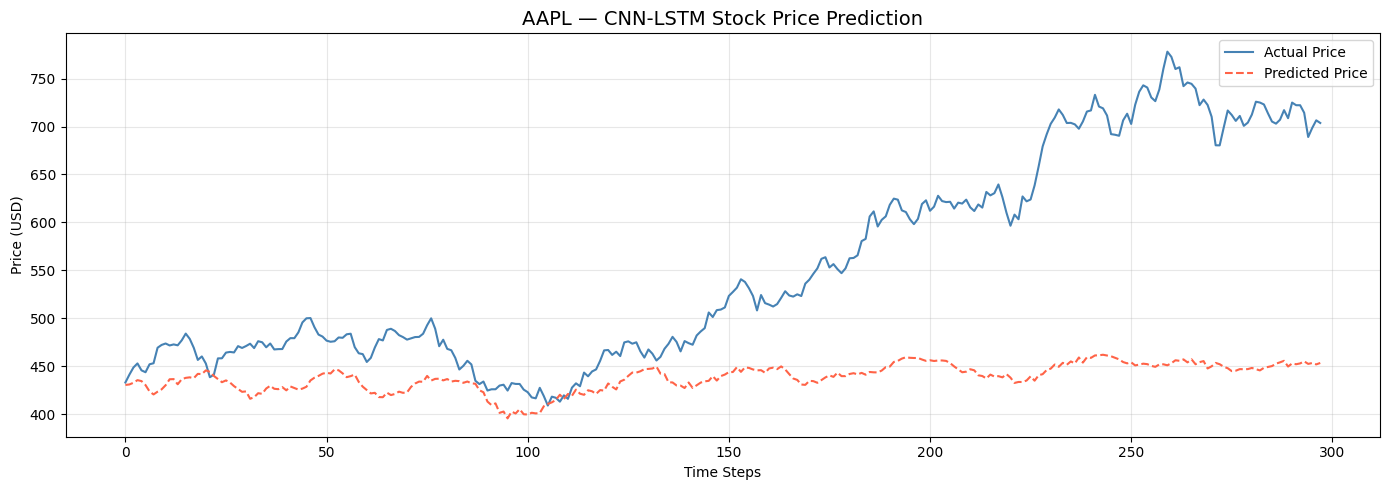

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(y_true, label='Actual Price', color='steelblue', linewidth=1.5)
plt.plot(y_pred, label='Predicted Price', color='tomato', linewidth=1.5, linestyle='--')
plt.title(f'{TICKER} — CNN-LSTM Stock Price Prediction', fontsize=14)
plt.xlabel('Time Steps')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
last_seq = scaled_features[-SEQ_LEN:].reshape(1, SEQ_LEN, len(feature_cols))
next_pred_scaled = model.predict(last_seq)
next_pred = scaler_target.inverse_transform(next_pred_scaled)
print(f'Predicted next closing price for {TICKER}: ${next_pred[0][0]:.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


Predicted next closing price for AAPL: $453.25


In [13]:
model.save('cnn_lstm_stock_model.h5')
print('Model saved as cnn_lstm_stock_model.h5')

Model saved as cnn_lstm_stock_model.h5
